# Telco Customer Churn Prediction

## Business Problem
A telecommunications company wants to identify customers likely to churn so the retention team can engage proactively. This notebook builds an end-to-end churn prediction workflow using the IBM Telco Customer Churn dataset.

**Target variable:** Churn (Yes / No)


In [18]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

from src.preprocessing import (
    SERVICE_COLUMNS,
    build_model_pipeline,
    load_and_clean_data,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

DATA_PATH = PROJECT_ROOT / 'data' / 'TelcoCustomerChurn.csv'
MODEL_PATH = PROJECT_ROOT / 'model' / 'churn_model.pkl'

print('Project root:', PROJECT_ROOT)


Project root: C:\Users\vivekkumar04\Downloads\Home Assignment - Technology Band III\customer_churn_project


## 1. Data Understanding & Preparation


In [19]:
raw_df = pd.read_csv(DATA_PATH)
print('Shape:', raw_df.shape)
print('\nColumns and dtypes:')
print(raw_df.dtypes)
raw_df.head()


Shape: (7043, 21)

Columns and dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
print('Missing values:')
print(raw_df.isna().sum())

blank_total_charges = (raw_df['TotalCharges'].astype(str).str.strip() == '').sum()
print('\nBlank TotalCharges values:', blank_total_charges)
print('Duplicate rows:', raw_df.duplicated().sum())

numerical_cols = raw_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = [col for col in raw_df.columns if col not in numerical_cols]
print('\nNumerical columns:', numerical_cols)
print('Categorical columns:', categorical_cols)
print('\nTarget distribution:')
print(raw_df['Churn'].value_counts(normalize=True))


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank TotalCharges values: 11
Duplicate rows: 0

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Target distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [21]:
df = load_and_clean_data(DATA_PATH)

print('Cleaned shape:', df.shape)
print('TotalCharges missing after cleaning:', df['TotalCharges'].isna().sum())
df.head()


Cleaned shape: (7043, 20)
TotalCharges missing after cleaning: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))
print('Train churn rate:', y_train.value_counts(normalize=True).to_dict())


Train size: 4930
Test size: 2113
Train churn rate: {'No': 0.734685598377282, 'Yes': 0.2653144016227181}


### Preprocessing decisions
- Dropped customerID because it is an identifier with no predictive value.
- Converted TotalCharges to numeric and replaced blank values for new customers (	enure = 0) with MonthlyCharges.
- Encoded categorical variables inside a sklearn pipeline using one-hot encoding to avoid leakage and support unseen categories.
- Engineered features are created in a reusable transformer so training and API inference stay consistent.


## 2. Exploratory Data Analysis


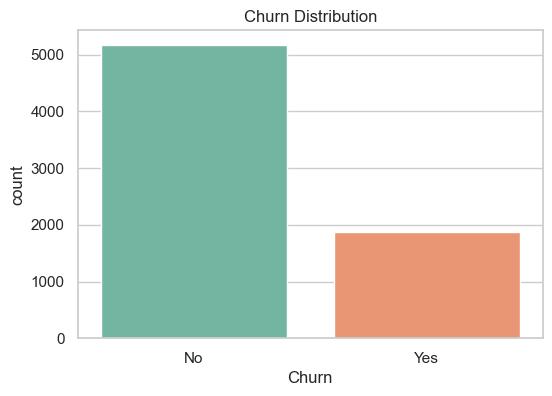

Insight: Churn is imbalanced (~26% Yes), so accuracy alone can be misleading.


In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2', ax=ax)
ax.set_title('Churn Distribution')
plt.show()

print('Insight: Churn is imbalanced (~26% Yes), so accuracy alone can be misleading.')


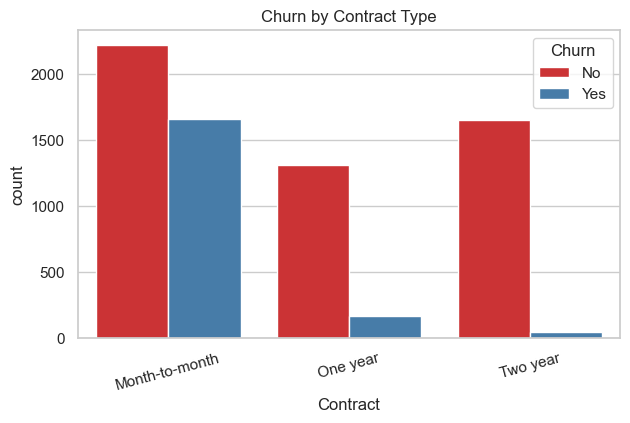

Insight: Month-to-month contracts have the highest churn rate, suggesting contract flexibility increases attrition risk.


: 

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1', ax=ax)
ax.set_title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

print('Insight: Month-to-month contracts have the highest churn rate, suggesting contract flexibility increases attrition risk.')


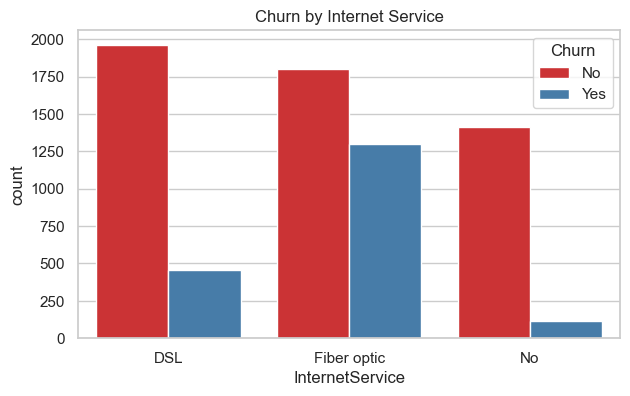

Insight: Fiber optic customers churn more often than DSL customers, possibly due to pricing or service expectations.


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1', ax=ax)
ax.set_title('Churn by Internet Service')
plt.show()

print('Insight: Fiber optic customers churn more often than DSL customers, possibly due to pricing or service expectations.')


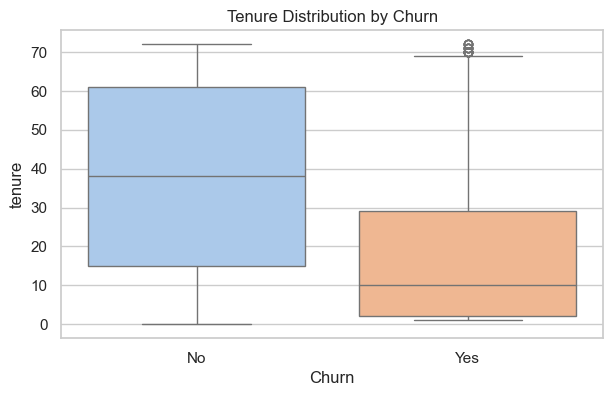

Insight: Customers who churn typically have lower tenure, indicating early lifecycle is a critical retention period.


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Churn', y='tenure', palette='pastel', ax=ax)
ax.set_title('Tenure Distribution by Churn')
plt.show()

print('Insight: Customers who churn typically have lower tenure, indicating early lifecycle is a critical retention period.')


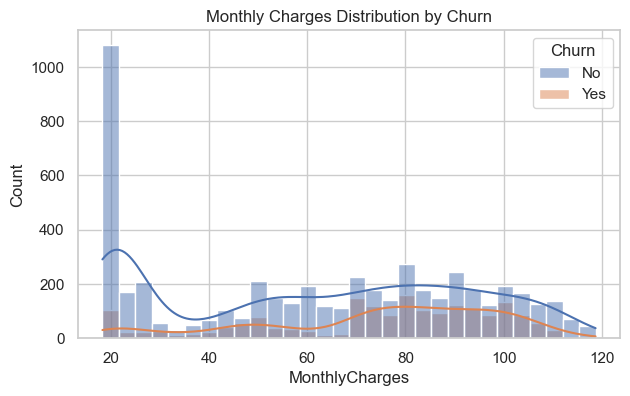

Insight: Higher monthly charges are associated with greater churn, especially among premium service users.


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, ax=ax)
ax.set_title('Monthly Charges Distribution by Churn')
plt.show()

print('Insight: Higher monthly charges are associated with greater churn, especially among premium service users.')


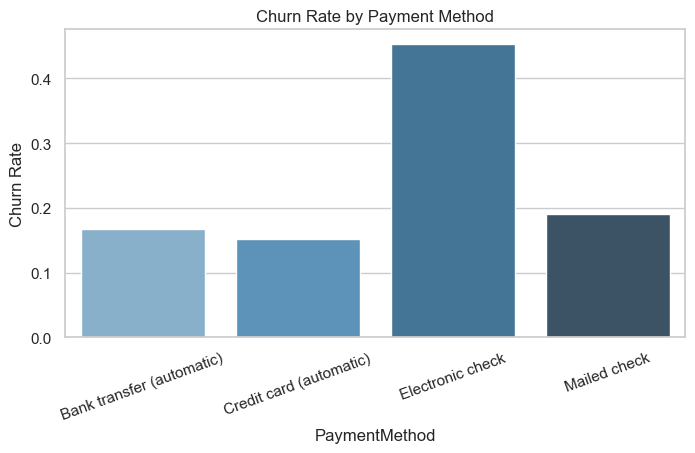

Insight: Electronic check users show higher churn, which may reflect lower commitment or payment friction.


In [11]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .rename('rate')
    .reset_index()
)
payment_churn = payment_churn[payment_churn['Churn'] == 'Yes']

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='rate', palette='Blues_d', ax=ax)
ax.set_title('Churn Rate by Payment Method')
ax.set_ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.show()

print('Insight: Electronic check users show higher churn, which may reflect lower commitment or payment friction.')


## 3. Feature Engineering


In [12]:
engineered = df.copy()
engineered['AvgMonthlyCharge'] = engineered['TotalCharges'] / engineered['tenure'].replace(0, np.nan)
engineered['AvgMonthlyCharge'] = engineered['AvgMonthlyCharge'].fillna(engineered['MonthlyCharges'])
engineered['NumAddOnServices'] = engineered[SERVICE_COLUMNS].eq('Yes').sum(axis=1)
engineered['IsMonthToMonth'] = (engineered['Contract'] == 'Month-to-month').astype(int)

engineered[['AvgMonthlyCharge', 'NumAddOnServices', 'IsMonthToMonth', 'Churn']].head()


,AvgMonthlyCharge,NumAddOnServices,IsMonthToMonth,Churn
0,29.850000,1,1,No
1,55.573529,2,0,No
2,54.075000,2,1,Yes
3,40.905556,3,0,No
4,75.825000,0,1,Yes


### Engineered features
1. **AvgMonthlyCharge** = TotalCharges / tenure (with safe handling for tenure = 0). Captures realized spend per month and may separate high-spend loyal customers from expensive short-tenure churners.
2. **NumAddOnServices** = count of subscribed add-on services. More services can indicate deeper engagement and lower churn risk.
3. **IsMonthToMonth** = binary indicator for month-to-month contracts, which EDA showed are strongly linked to churn.


## 4. Model Development


In [13]:
model_configs = {
    'baseline_tree': build_model_pipeline(),
    'tuned_tree': build_model_pipeline(
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced',
    ),
}

results = []
fitted_models = {}

for name, model in model_configs.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, pos_label='Yes'),
        'recall': recall_score(y_test, preds, pos_label='Yes'),
        'f1': f1_score(y_test, preds, pos_label='Yes'),
    }
    results.append(metrics)
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
results_df


,model,accuracy,precision,recall,f1
1,tuned_tree,0.732608,0.497706,0.773619,0.605722
0,baseline_tree,0.727875,0.487847,0.500891,0.494283


### Model selection
- **Baseline tree:** default decision tree hyperparameters.
- **Tuned tree:** limited depth, larger minimum leaf size, and balanced class weights to reduce overfitting and improve recall on the minority churn class.

The tuned tree is preferred when it delivers better F1/recall while maintaining reasonable precision.


## 5. Model Evaluation


Selected model: tuned_tree

Classification report:
              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1552
         Yes       0.50      0.77      0.61       561

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.70      2113
weighted avg       0.79      0.73      0.75      2113



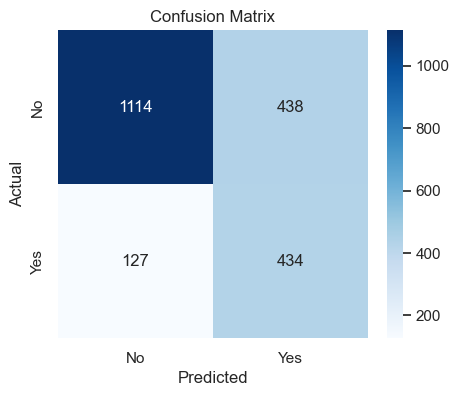

In [14]:
final_model_name = results_df.iloc[0]['model']
final_model = fitted_models[final_model_name]
final_preds = final_model.predict(X_test)

print('Selected model:', final_model_name)
print('\nClassification report:')
print(classification_report(y_test, final_preds))

cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.show()


### Business interpretation
For churn retention, **recall is usually more important than precision** because missing a customer who will churn (false negative) is often costlier than contacting a loyal customer with a retention offer (false positive). The retention team can tolerate some extra outreach, but it cannot afford to miss high-risk customers.

That said, precision still matters if outreach is expensive, so F1 is a practical balance metric for model comparison.


## 6. Model Interpretation


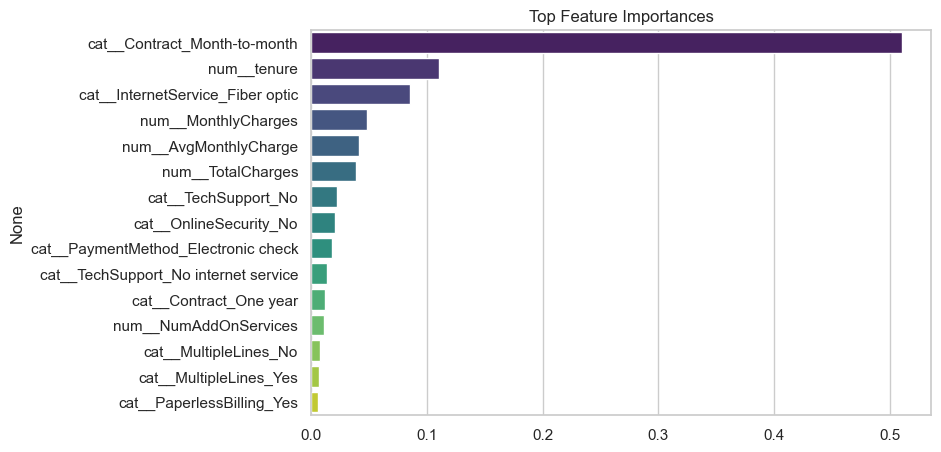

cat__Contract_Month-to-month            0.510533
num__tenure                             0.110775
cat__InternetService_Fiber optic        0.085023
num__MonthlyCharges                     0.047869
num__AvgMonthlyCharge                   0.041174
num__TotalCharges                       0.038376
cat__TechSupport_No                     0.022248
cat__OnlineSecurity_No                  0.020456
cat__PaymentMethod_Electronic check     0.018217
cat__TechSupport_No internet service    0.013826
dtype: float64

In [15]:
preprocessor = final_model.named_steps['preprocessor']
classifier = final_model.named_steps['classifier']

feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(classifier.feature_importances_, index=feature_names).sort_values(ascending=False)

top_features = importances.head(15)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', ax=ax)
ax.set_title('Top Feature Importances')
plt.show()

top_features.head(10)


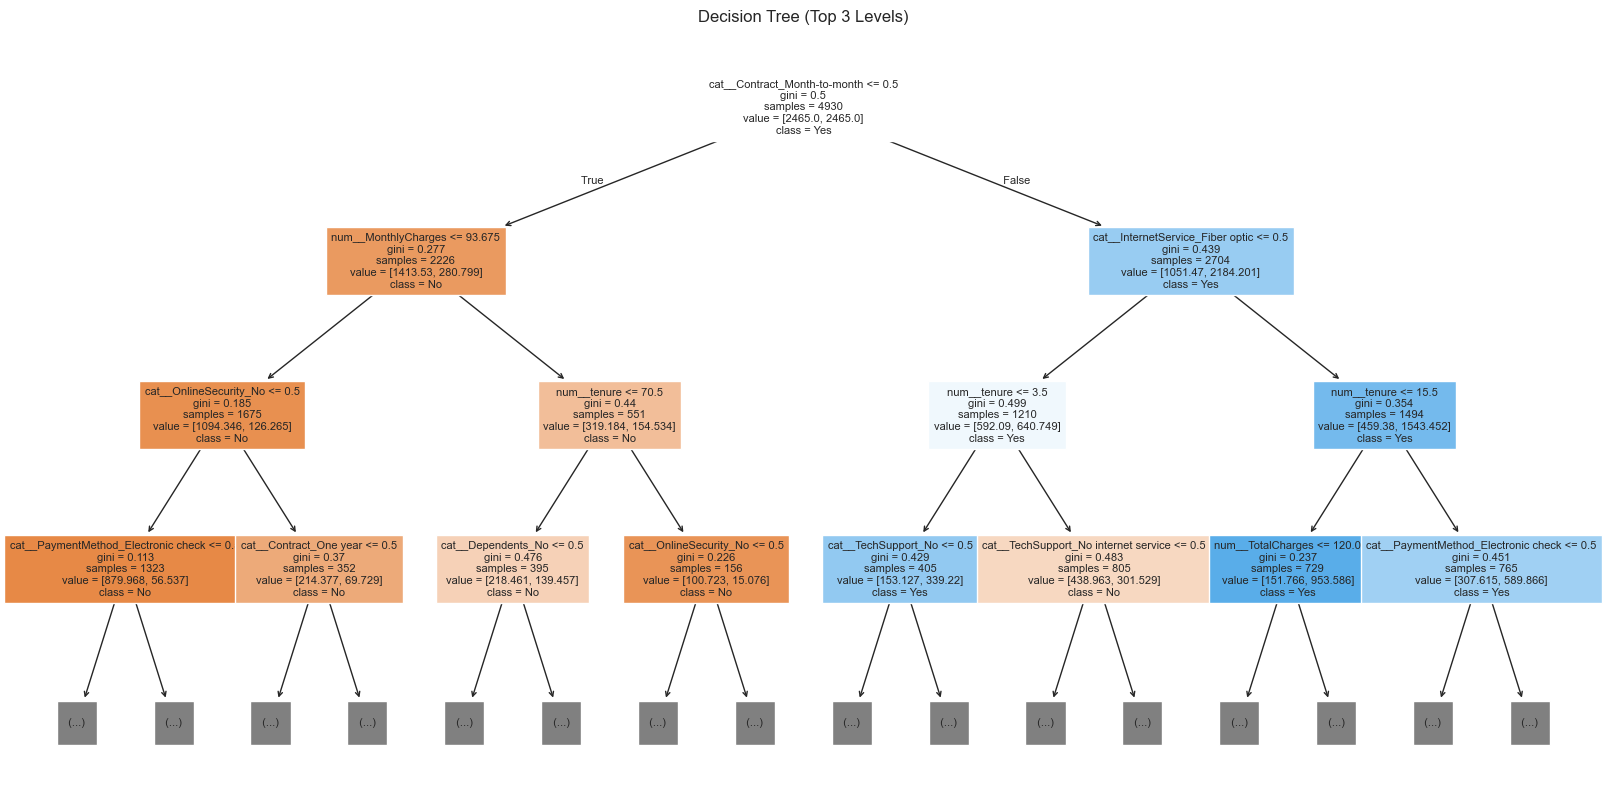

Key drivers typically include contract type, tenure, monthly charges, and internet service type.


In [16]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    classifier,
    feature_names=feature_names,
    class_names=classifier.classes_,
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title('Decision Tree (Top 3 Levels)')
plt.show()

print('Key drivers typically include contract type, tenure, monthly charges, and internet service type.')


## 7. Save Model & Pipeline


In [17]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
print('Saved model to', MODEL_PATH)


Saved model to C:\Users\vivekkumar04\Downloads\Home Assignment - Technology Band III\customer_churn_project\model\churn_model.pkl


## 8. API Usage
After training, start the API with:

`ash
uvicorn app:app --reload
`

Then send a POST request to /predict using sample_request.json.
